# 03 — Model Training (Local, CPU)
## Shared frozen EfficientNetB0 backbone + per-crop heads, via cached feature extraction

**Why this design:** running the full CNN on every image on every epoch is what made the earlier attempt take 1h18m for a single crop. Here, every image is passed through the frozen backbone **once** to extract a 1280-dim feature vector (cached to disk), then each crop's small head trains on those cached vectors — fast, since it's just a small dense network, not a CNN forward pass, on every epoch.

**This also fixes a real bug from the previous attempt:** the backbone here is NEVER set trainable and NEVER reused as a mutable object across crops — each crop's head is a fully separate small model trained on static, pre-computed features. No shared-state corruption between crops is possible by construction.

**Outputs:**
- `ml-service/data/features/<crop>_<split>.npz` — cached backbone features (one-time)
- `ml-service/models/heads/<crop>_head.keras` — small per-crop head (few hundred KB, not bundled with the backbone)
- `ml-service/models/training_history.json`, `test_results.json`

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json, time, warnings
warnings.filterwarnings("ignore", category=UserWarning)

ROOT = Path(r"D:\AI Plant Disease Detection System")
DATA = ROOT / "ml-service" / "data"
MODELS_DIR = ROOT / "ml-service" / "models"
FEATURES_DIR = DATA / "features"
HEADS_DIR = MODELS_DIR / "heads"
FIG_DIR = DATA / "eda_figures"

FEATURES_DIR.mkdir(parents=True, exist_ok=True)
HEADS_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE
ACTIVE_CROPS = ["wheat", "rice", "sugarcane", "potato", "maize", "pigeonpea"]
EPOCHS = 30
PATIENCE = 5

sns.set_theme(style="whitegrid", font_scale=1.15)
print(f"TensorFlow {tf.__version__}")


TensorFlow 2.21.0


## 1. Load dataset index and label/weight maps (from 01_eda / 02_preprocessing)

In [2]:
df = pd.read_csv(DATA / "dataset_index.csv")
label_maps = json.load(open(DATA / "label_maps.json"))
class_weights = json.load(open(DATA / "class_weights.json"))
print(f"Index loaded: {len(df):,} images, {len(label_maps)} crops")


Index loaded: 36,848 images, 6 crops


## 2. Shared frozen backbone — built ONCE, never modified
Used only for inference (feature extraction). Never set `trainable = True` anywhere in this notebook.

In [3]:
base_model = EfficientNetB0(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

backbone = Model(
    inputs=base_model.input,
    outputs=layers.GlobalAveragePooling2D()(base_model.output),
    name="efficientnetb0_backbone",
)
print(f"Backbone output: {backbone.output_shape[1]}-dim features, frozen, {backbone.count_params():,} params")


Backbone output: 1280-dim features, frozen, 4,049,571 params


## 3. Feature extraction (one-time cost across all crops/splits)
This is the slow-ish step, but it only runs once — cached `.npz` files mean re-running this notebook later skips straight to the fast part.

In [4]:
def load_image(filepath):
    img = tf.io.read_file(filepath)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    return preprocess_input(img)

def extract_features(crop, split):
    cache_path = FEATURES_DIR / f"{crop}_{split}.npz"
    if cache_path.exists():
        d = np.load(cache_path)
        return d["features"], d["labels"]

    subset = df[(df["crop"] == crop) & (df["split"] == split)]
    filepaths = [str(DATA / fp) for fp in subset["filepath"].values]
    labels = subset["label"].values.astype(np.int32) if "label" in subset.columns else \
             subset.apply(lambda r: label_maps[r["crop"]][r["class"]], axis=1).values.astype(np.int32)

    ds = tf.data.Dataset.from_tensor_slices(filepaths)
    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE).batch(BATCH_SIZE).prefetch(AUTOTUNE)

    t0 = time.time()
    features = backbone.predict(ds, verbose=1)
    print(f"  {crop}/{split}: {len(labels)} images -> features {features.shape} in {(time.time()-t0)/60:.1f} min")

    np.savez(cache_path, features=features, labels=labels)
    return features, labels

if "label" not in df.columns:
    df["label"] = df.apply(lambda r: label_maps[r["crop"]][r["class"]], axis=1)

feature_cache = {}
for crop in ACTIVE_CROPS:
    print(f"\nExtracting features: {crop}")
    for split in ["train", "val", "test"]:
        feature_cache[(crop, split)] = extract_features(crop, split)



Extracting features: wheat

Extracting features: rice

Extracting features: sugarcane

Extracting features: potato

Extracting features: maize

Extracting features: pigeonpea


## 4. Per-crop head training — fast, small models, trained on cached features

In [5]:
def build_head(num_classes):
    inputs = keras.Input(shape=(1280,))
    x = layers.Dense(128, activation="relu")(inputs)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = Model(inputs, outputs)
    model.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

all_history = {}
crop_results = []

for crop in ACTIVE_CROPS:
    n_classes = len(label_maps[crop])
    cw = {int(k): v for k, v in class_weights[crop].items()}

    X_train, y_train = feature_cache[(crop, "train")]
    X_val, y_val = feature_cache[(crop, "val")]

    print(f"\n{'='*50}\n{crop.upper()} — {n_classes} classes, {len(y_train)} train samples\n{'='*50}")

    model = build_head(n_classes)
    t0 = time.time()
    history = model.fit(
        X_train, y_train, validation_data=(X_val, y_val),
        epochs=EPOCHS, batch_size=64, class_weight=cw,
        callbacks=[
            EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, verbose=1),
            ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
        ],
        verbose=1,
    )
    elapsed = (time.time() - t0) / 60

    head_path = HEADS_DIR / f"{crop}_head.keras"
    model.save(head_path)  # small file: head only, no backbone bundled

    all_history[crop] = {k: [float(x) for x in v] for k, v in history.history.items()}
    best_val_acc = max(history.history["val_accuracy"])
    crop_results.append({
        "crop": crop, "classes": n_classes,
        "best_val_acc": round(best_val_acc, 4),
        "epochs_trained": len(history.history["loss"]),
        "time_min": round(elapsed, 2),
    })
    print(f"{crop}: best_val_acc={best_val_acc:.4f}, took {elapsed:.2f} min, saved {head_path.name} ({head_path.stat().st_size/1e6:.2f} MB)")

json.dump(all_history, open(MODELS_DIR / "training_history.json", "w"), indent=2)
print("\nSaved training_history.json")



WHEAT — 6 classes, 11622 train samples
Epoch 1/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9866 - loss: 0.2038 - val_accuracy: 0.9984 - val_loss: 0.0061 - learning_rate: 0.0010
Epoch 2/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9985 - loss: 0.0467 - val_accuracy: 0.9980 - val_loss: 0.0057 - learning_rate: 0.0010
Epoch 3/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9988 - loss: 0.0318 - val_accuracy: 0.9988 - val_loss: 0.0036 - learning_rate: 0.0010
Epoch 4/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9991 - loss: 0.0270 - val_accuracy: 0.9984 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 5/30
170/182 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9997 - loss: 0.0093
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9997 - loss: 0.0105 - val_accuracy: 0.9988 - val_loss: 0.0039 - learning_rate: 0.0010
Epoch 6/30
182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/st

## 5. Results summary

In [6]:
results_df = pd.DataFrame(crop_results)
print(results_df.to_string(index=False))
print(f"\nMean val accuracy: {results_df['best_val_acc'].mean():.4f}")
print(f"Total head training time: {results_df['time_min'].sum():.1f} min (feature extraction was separate, one-time cost above)")


     crop  classes  best_val_acc  epochs_trained  time_min
    wheat        6        0.9992              12      0.11
     rice        5        1.0000              30      0.13
sugarcane       11        0.9219              25      0.11
   potato        3        0.9876              15      0.04
    maize        4        0.9618              13      0.05
pigeonpea        4        0.8069              15      0.03

Mean val accuracy: 0.9462
Total head training time: 0.5 min (feature extraction was separate, one-time cost above)


## 6. Test set evaluation + confusion matrices


WHEAT — Test Accuracy: 0.9992
                 precision    recall  f1-score   support

     BlackPoint     1.0000    1.0000    1.0000        46
FusariumFootRot     0.9487    1.0000    0.9737        37
    HealthyLeaf     1.0000    0.9730    0.9863        37
     LeafBlight     1.0000    0.9833    0.9916        60
     WheatBlast     1.0000    1.0000    1.0000        60
    Yellow_Rust     1.0000    1.0000    1.0000      2250

       accuracy                         0.9992      2490
      macro avg     0.9915    0.9927    0.9919      2490
   weighted avg     0.9992    0.9992    0.9992      2490


RICE — Test Accuracy: 0.9978
                 precision    recall  f1-score   support

Bacterialblight     0.9958    1.0000    0.9979       237
          Blast     1.0000    1.0000    1.0000       216
      Brownspot     1.0000    1.0000    1.0000       240
        Healthy     1.0000    0.9474    0.9730        38
         Tungro     0.9949    1.0000    0.9975       196

       accuracy       

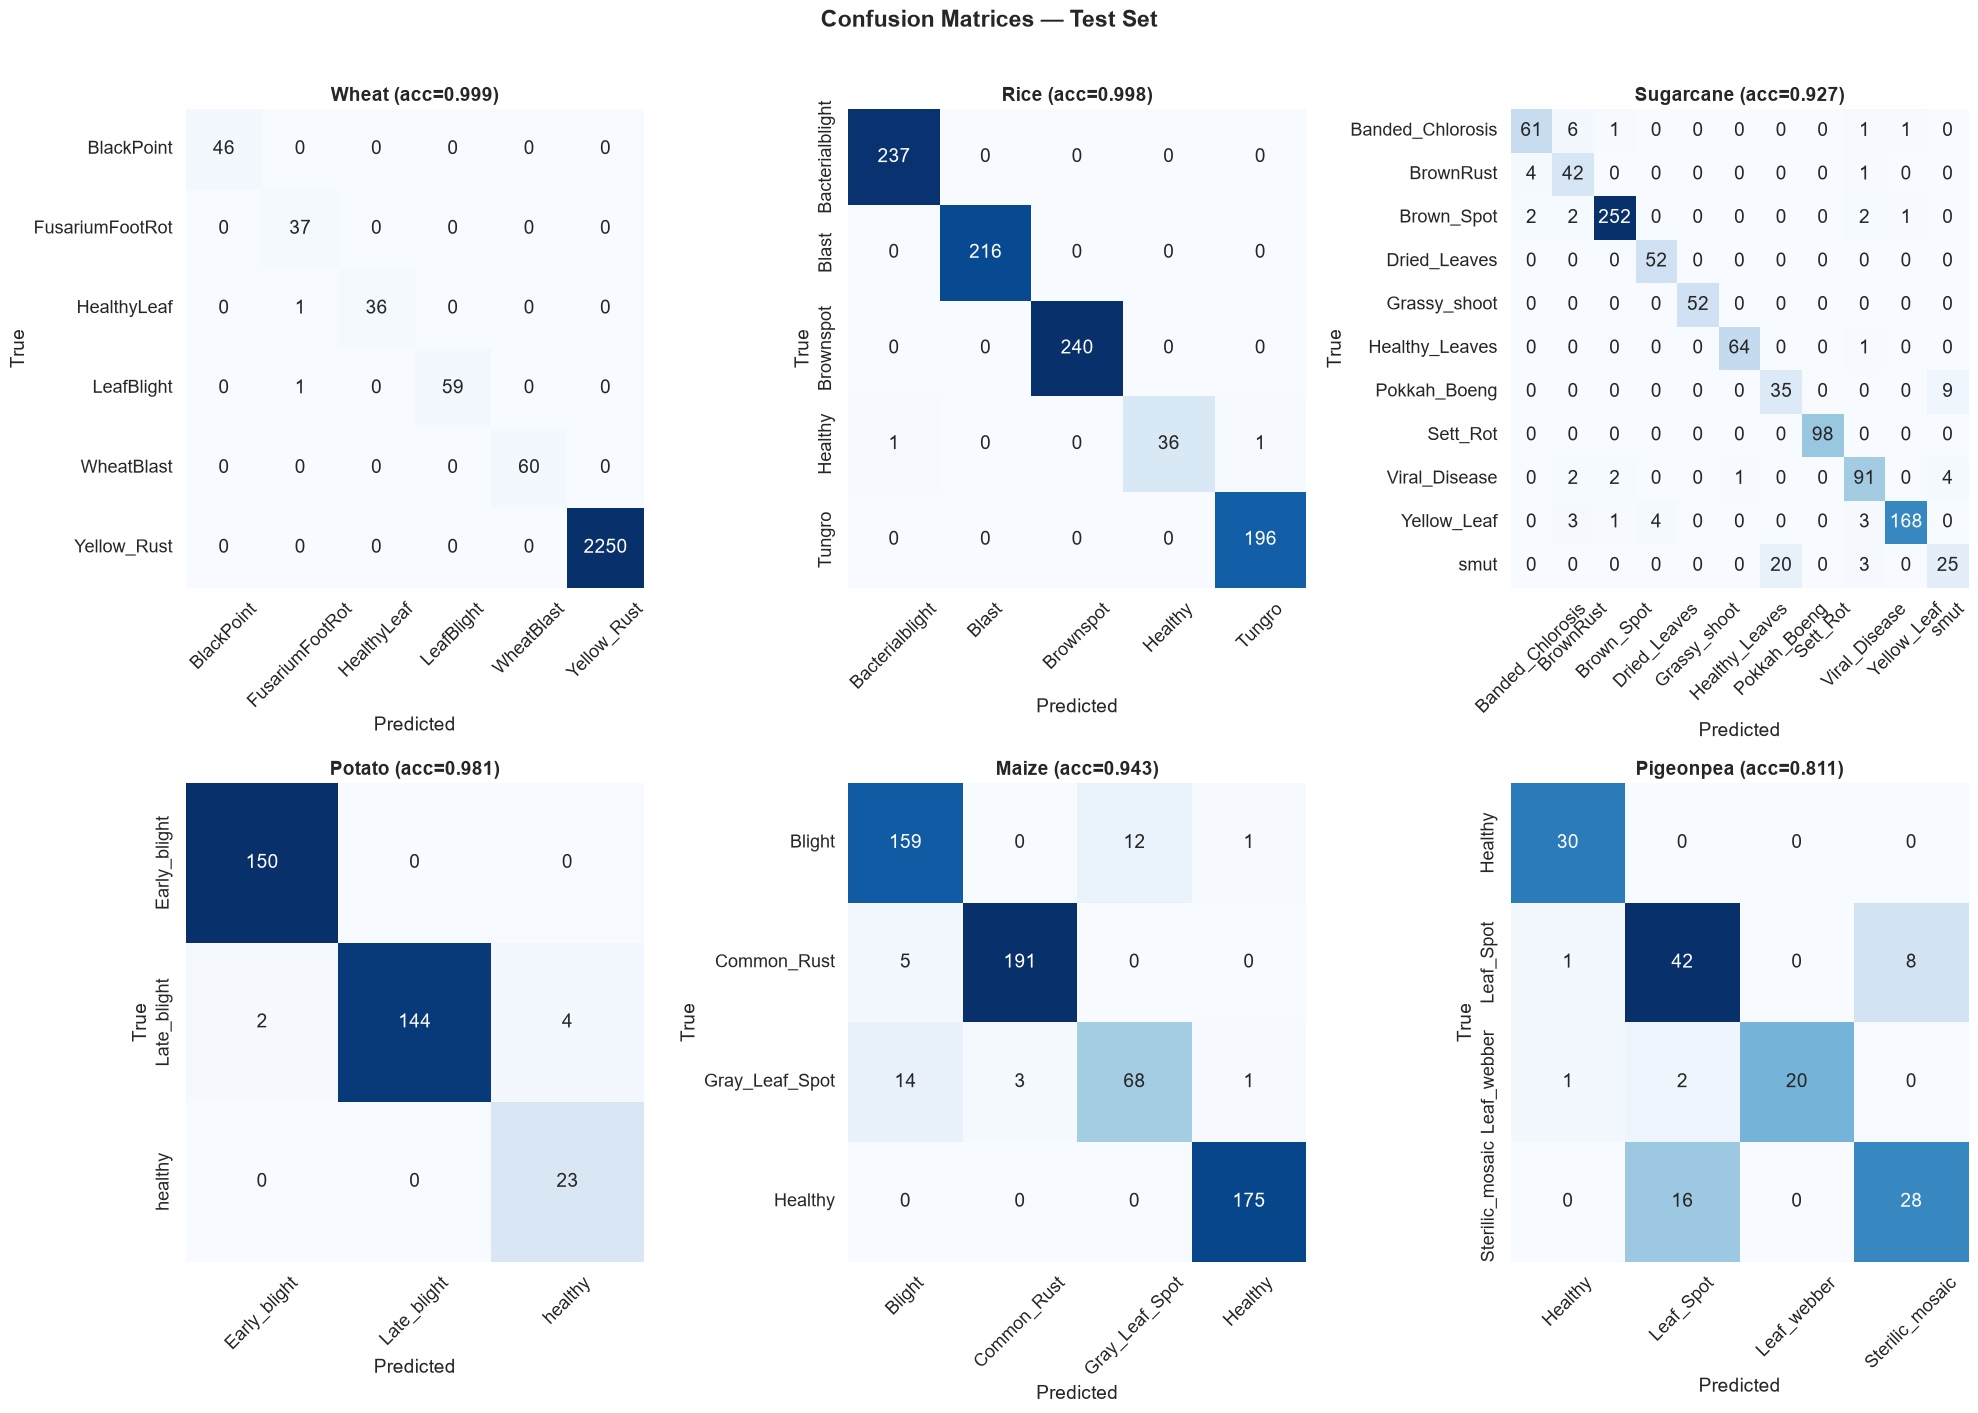


      crop  test_acc  test_n
    wheat    0.9992    2490
     rice    0.9978     927
sugarcane    0.9270    1014
   potato    0.9814     323
    maize    0.9428     629
pigeonpea    0.8108     148

Mean test accuracy: 0.9432


In [7]:
from sklearn.metrics import classification_report, confusion_matrix

test_results = []
fig, axes = plt.subplots(2, 3, figsize=(20, 14))
fig.suptitle("Confusion Matrices — Test Set", fontweight="bold", y=1.01)

for idx, crop in enumerate(ACTIVE_CROPS):
    model = keras.models.load_model(HEADS_DIR / f"{crop}_head.keras")
    X_test, y_test = feature_cache[(crop, "test")]
    inv_map = {v: k for k, v in label_maps[crop].items()}
    class_names = [inv_map[i] for i in range(len(inv_map))]

    preds = model.predict(X_test, verbose=0)
    y_pred = np.argmax(preds, axis=1)
    test_acc = (y_test == y_pred).mean()
    test_results.append({"crop": crop, "test_acc": round(test_acc, 4), "test_n": len(y_test)})

    print(f"\n{'='*50}\n{crop.upper()} — Test Accuracy: {test_acc:.4f}\n{'='*50}")
    print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

    ax = axes[idx // 3, idx % 3]
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names,
                yticklabels=class_names, ax=ax, cbar=False)
    ax.set_title(f"{crop.title()} (acc={test_acc:.3f})", fontweight="bold")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
fig.savefig(FIG_DIR / "09_confusion_matrices.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

test_df = pd.DataFrame(test_results)
json.dump(test_results, open(MODELS_DIR / "test_results.json", "w"), indent=2)
test_df.to_csv(MODELS_DIR / "test_results.csv", index=False)
print("\n", test_df.to_string(index=False))
print(f"\nMean test accuracy: {test_df['test_acc'].mean():.4f}")


## 7. Correction: Yellow_Rust removed from wheat (see Grad-CAM diagnostic)

Grad-CAM analysis (separate notebook) showed Yellow_Rust's 100% classification 
accuracy was driven by a photography-style shortcut (YR-19's macro/dark-background 
photos vs. the other 5 classes' natural field photos), not genuine rust-symptom 
detection. Yellow_Rust is removed from wheat's disease-classification task below. 
YR-19's expert severity grades remain valid and unaffected — they were never used 
for this classification task, only for severity-label validation.

In [9]:
# Assumes feature_cache, label_maps, class_weights already loaded from the training notebook

wheat_yr_idx = label_maps["wheat"]["Yellow_Rust"]

def strip_yellow_rust(X, y):
    mask = y != wheat_yr_idx
    X_filtered = X[mask]
    y_filtered = y[mask]
    # remap remaining labels to be contiguous (0-4 instead of 0-5 with a gap)
    remaining_labels = sorted(set(y_filtered.tolist()))
    remap = {old: new for new, old in enumerate(remaining_labels)}
    y_remapped = np.array([remap[v] for v in y_filtered])
    return X_filtered, y_remapped, remap

X_train, y_train_raw = feature_cache[("wheat", "train")]
X_val, y_val_raw = feature_cache[("wheat", "val")]
X_test, y_test_raw = feature_cache[("wheat", "test")]

X_train_5c, y_train_5c, remap = strip_yellow_rust(X_train, y_train_raw)
X_val_5c, y_val_5c, _ = strip_yellow_rust(X_val, y_val_raw)
X_test_5c, y_test_5c, _ = strip_yellow_rust(X_test, y_test_raw)

new_wheat_classes = {v: k for k, v in remap.items()}  # new_idx -> old_idx, for reference
new_label_map = {name: remap[old_idx] for name, old_idx in label_maps["wheat"].items() if old_idx in remap}
print("New wheat classes (5):", new_label_map)

# Rebuild class weights for the 5-class version
old_cw = class_weights["wheat"]
new_cw = {remap[int(k)]: v for k, v in old_cw.items() if int(k) in remap}

model = build_head(num_classes=5)
history = model.fit(
    X_train_5c, y_train_5c, validation_data=(X_val_5c, y_val_5c),
    epochs=EPOCHS, batch_size=64, class_weight=new_cw,
    callbacks=[EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)],
    verbose=1,
)

model.save(HEADS_DIR / "wheat_head.keras")  # overwrite the old 6-class version

test_preds = np.argmax(model.predict(X_test_5c), axis=1)
test_acc = (test_preds == y_test_5c).mean()
print(f"Wheat (5-class, no Yellow_Rust) test accuracy: {test_acc:.4f}")

New wheat classes (5): {'BlackPoint': 0, 'FusariumFootRot': 1, 'HealthyLeaf': 2, 'LeafBlight': 3, 'WheatBlast': 4}
Epoch 1/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8512 - loss: 4.5119 - val_accuracy: 0.9710 - val_loss: 0.1211
Epoch 2/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9688 - loss: 1.0384 - val_accuracy: 0.9793 - val_loss: 0.0673
Epoch 3/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9848 - loss: 0.5352 - val_accuracy: 0.9834 - val_loss: 0.0571
Epoch 4/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9902 - loss: 0.3853 - val_accuracy: 0.9917 - val_loss: 0.0454
Epoch 5/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9911 - loss: 0.3255 - val_accuracy: 0.9917 - val_loss: 0.0419
Epoch 6/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9947 - loss: 0.2410 - val_accuracy: 0.9917 - val_loss: 0.0426
Epoch 7/30
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9938 - loss: 0.2299 - val_accuracy: 0.9917 - val_loss: 0.0406
Ep

In [10]:
import json

# from the retrain cell's variables: new_label_map, new_cw
label_maps["wheat"] = new_label_map
class_weights["wheat"] = {str(k): v for k, v in new_cw.items()}

with open(DATA / "label_maps.json", "w") as f:
    json.dump(label_maps, f, indent=2)
with open(DATA / "class_weights.json", "w") as f:
    json.dump(class_weights, f, indent=2)

print("Updated wheat entry in label_maps.json and class_weights.json:")
print(new_label_map)

Updated wheat entry in label_maps.json and class_weights.json:
{'BlackPoint': 0, 'FusariumFootRot': 1, 'HealthyLeaf': 2, 'LeafBlight': 3, 'WheatBlast': 4}
